In [1]:
import scipy.io
import numpy as np

# Load the dataset
mat = scipy.io.loadmat('data/processed/WildPPG.mat')

# See what keys are inside
print("Keys in the file:")
for key in mat.keys():
    if not key.startswith('_'):
        print(f"  {key}  →  {mat[key].shape}")

Keys in the file:
  data_bpm_values  →  (16, 1)
  data_altitude_values  →  (16, 1)
  data_ppg_chest  →  (16, 1)
  data_ppg_head  →  (16, 1)
  data_ppg_ankle  →  (16, 1)
  data_ppg_wrist  →  (16, 1)
  data_temp_chest  →  (16, 1)
  data_temp_head  →  (16, 1)
  data_temp_ankle  →  (16, 1)
  data_temp_wrist  →  (16, 1)
  data_imu_chest  →  (16, 1)
  data_imu_head  →  (16, 1)
  data_imu_ankle  →  (16, 1)
  data_imu_wrist  →  (16, 1)


In [2]:
ppg_wrist = mat['data_ppg_wrist']   # shape (16, 1)
bpm       = mat['data_bpm_values']  # shape (16, 1)

# Get subject 0's data
subject0_ppg = ppg_wrist[0, 0]
subject0_bpm = bpm[0, 0]

print("Subject 0 PPG wrist shape:", subject0_ppg.shape)
print("Subject 0 BPM shape:      ", subject0_bpm.shape)
print()
print("PPG value range:", subject0_ppg.min(), "to", subject0_ppg.max())
print("BPM value range:", subject0_bpm.min(), "to", subject0_bpm.max())

Subject 0 PPG wrist shape: (5994, 200)
Subject 0 BPM shape:       (5994, 1)

PPG value range: nan to nan
BPM value range: 57.1307120085016 to 138.3783783783784


In [3]:
# Clean out the NaN windows
ppg_raw = subject0_ppg  # (5994, 200)
bpm_raw = subject0_bpm.flatten()  # (5994,)

# Find windows where PPG has no NaN and BPM is valid
mask = (~np.isnan(ppg_raw).any(axis=1)) & (~np.isnan(bpm_raw)) & (bpm_raw >= 30)

ppg_clean = ppg_raw[mask]
bpm_clean = bpm_raw[mask]

print(f"Total windows    : {len(ppg_raw)}")
print(f"Valid windows    : {mask.sum()}")
print(f"Removed (NaN)    : {(~mask).sum()}")
print()
print(f"Clean PPG shape  : {ppg_clean.shape}")
print(f"BPM range        : {bpm_clean.min():.1f} to {bpm_clean.max():.1f} bpm")
print(f"BPM mean         : {bpm_clean.mean():.1f} bpm")

Total windows    : 5994
Valid windows    : 5981
Removed (NaN)    : 13

Clean PPG shape  : (5981, 200)
BPM range        : 57.1 to 138.4 bpm
BPM mean         : 75.9 bpm


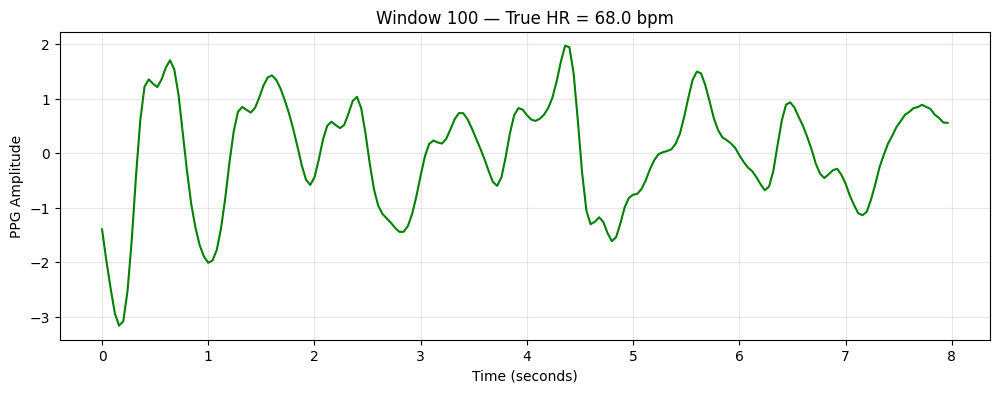

This is 8 seconds of green light PPG from the wrist
The ECG says the true heart rate during this window is 68.0 bpm
That means we should see roughly 9.1 heartbeat pulses in the plot


In [4]:
import matplotlib.pyplot as plt

# Pick one window and look at it
window_idx = 100
ppg_window = ppg_clean[window_idx]   # 200 samples = 8 seconds
true_hr    = bpm_clean[window_idx]

# Time axis: 200 samples at 25 Hz = 8 seconds
time = np.arange(200) / 25.0

plt.figure(figsize=(12, 4))
plt.plot(time, ppg_window, color='green', linewidth=1.5)
plt.xlabel('Time (seconds)')
plt.ylabel('PPG Amplitude')
plt.title(f'Window {window_idx} — True HR = {true_hr:.1f} bpm')
plt.grid(True, alpha=0.3)
plt.show()

print(f"This is 8 seconds of green light PPG from the wrist")
print(f"The ECG says the true heart rate during this window is {true_hr:.1f} bpm")
print(f"That means we should see roughly {true_hr/60*8:.1f} heartbeat pulses in the plot")

c:\Users\hrana\anaconda3\envs\ml_env_fixed\Lib\site-packages\numpy\_core\_methods.py:171: RuntimeWarning: invalid value encountered in reduce
  arrmean = umr_sum(arr, axis, dtype, keepdims=True, where=where)


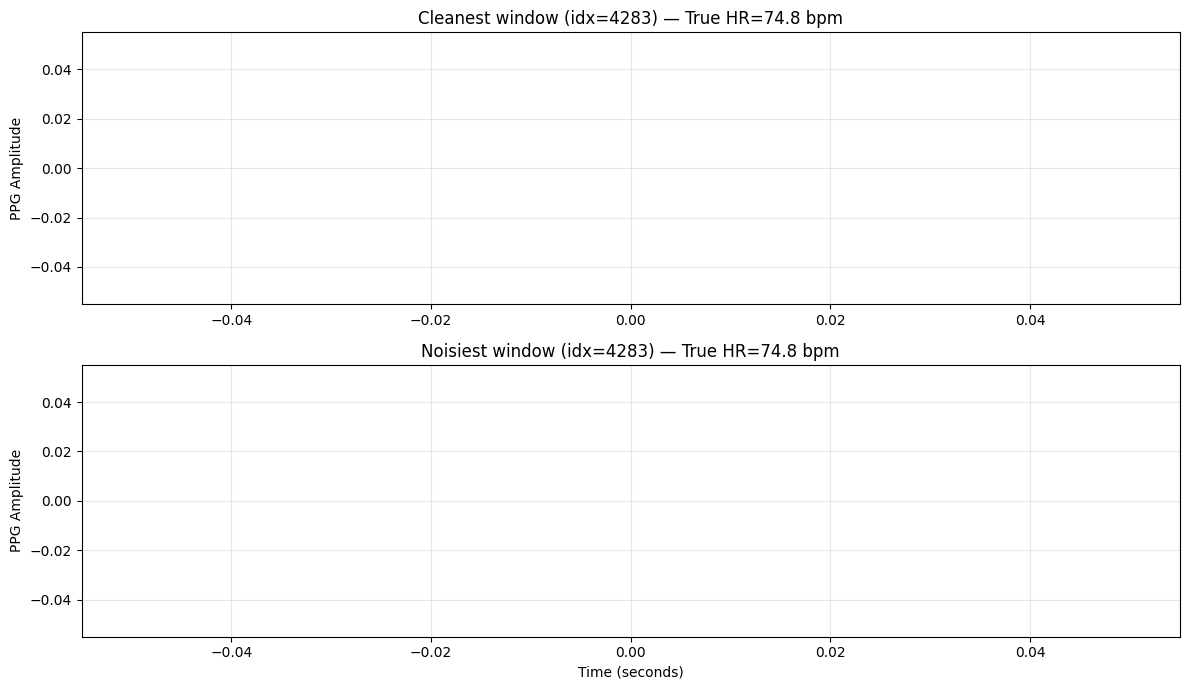

In [5]:
window_stds = ppg_clean.std(axis=1)

cleanest_idx = window_stds.argmin()
noisiest_idx = window_stds.argmax()

fig, axes = plt.subplots(2, 1, figsize=(12, 7))
time = np.arange(200) / 25.0

axes[0].plot(time, ppg_clean[cleanest_idx], color='green', linewidth=1.5)
axes[0].set_title(f'Cleanest window (idx={cleanest_idx}) — True HR={bpm_clean[cleanest_idx]:.1f} bpm')
axes[0].set_ylabel('PPG Amplitude')
axes[0].grid(True, alpha=0.3)

axes[1].plot(time, ppg_clean[noisiest_idx], color='red', linewidth=1.5)
axes[1].set_title(f'Noisiest window (idx={noisiest_idx}) — True HR={bpm_clean[noisiest_idx]:.1f} bpm')
axes[1].set_ylabel('PPG Amplitude')
axes[1].set_xlabel('Time (seconds)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [6]:
# Check what the "cleanest" window actually contains
print("Cleanest window values:", ppg_clean[cleanest_idx][:20])
print("Std of cleanest:", window_stds[cleanest_idx])
print()

# Let's find a better approach
# Look at std distribution to understand the data
print("Std statistics:")
print(f"  min: {window_stds.min():.4f}")
print(f"  max: {window_stds.max():.4f}")
print(f"  mean: {window_stds.mean():.4f}")
print()

# How many windows have std near zero?
print(f"Windows with std < 0.01: {(window_stds < 0.01).sum()}")
print(f"Windows with std > 0.1:  {(window_stds > 0.1).sum()}")

Cleanest window values: [inf inf inf inf inf inf inf inf inf inf inf inf inf inf inf inf inf inf
 inf inf]
Std of cleanest: nan

Std statistics:
  min: nan
  max: nan
  mean: nan

Windows with std < 0.01: 0
Windows with std > 0.1:  5885


In [7]:
# Better cleaning — remove NaN, inf, and zero-only windows
mask = (
    ~np.isnan(ppg_raw).any(axis=1) &   # no NaN
    ~np.isinf(ppg_raw).any(axis=1) &   # no infinity
    (bpm_raw >= 30) &                   # valid HR
    ~np.isnan(bpm_raw)
)

ppg_clean = ppg_raw[mask]
bpm_clean = bpm_raw[mask]

print(f"Valid windows after full cleaning: {len(ppg_clean)}")
print(f"Sample values from window 100: {ppg_clean[100][:5]}")
print(f"Std of window 100: {ppg_clean[100].std():.4f}")

Valid windows after full cleaning: 5885
Sample values from window 100: [-1.39544204 -1.96319422 -2.46813031 -2.93301144 -3.16361899]
Std of window 100: 1.0000


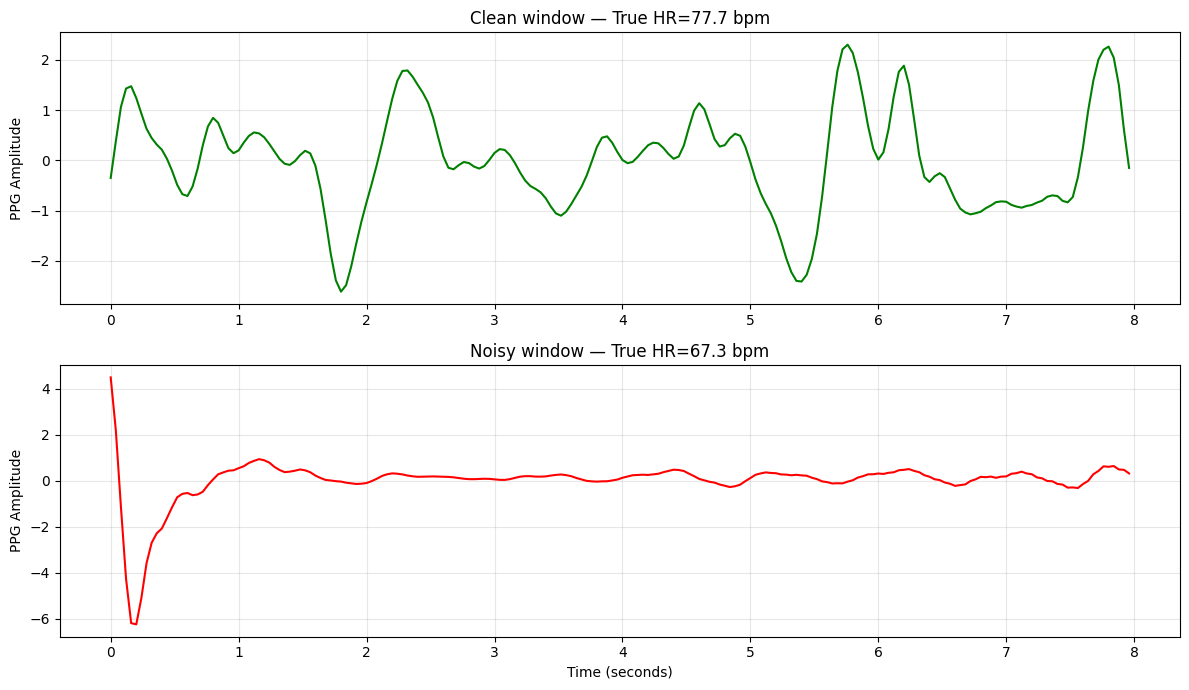

In [9]:
# Since data is pre-normalized, use peak-to-peak range as noise measure
# Clean PPG = smooth regular wave = moderate range
# Noisy PPG = wild swings = very large range

ppg_ranges = np.ptp(ppg_clean, axis=1)  # max - min per window

# Sort by range
sorted_idx = np.argsort(ppg_ranges)

cleanest_idx = sorted_idx[len(sorted_idx)//4]   # 25th percentile
noisiest_idx = sorted_idx[-10]                   # near the top

fig, axes = plt.subplots(2, 1, figsize=(12, 7))
time = np.arange(200) / 25.0

axes[0].plot(time, ppg_clean[cleanest_idx], color='green', linewidth=1.5)
axes[0].set_title(f'Clean window — True HR={bpm_clean[cleanest_idx]:.1f} bpm')
axes[0].set_ylabel('PPG Amplitude')
axes[0].grid(True, alpha=0.3)

axes[1].plot(time, ppg_clean[noisiest_idx], color='red', linewidth=1.5)
axes[1].set_title(f'Noisy window — True HR={bpm_clean[noisiest_idx]:.1f} bpm')
axes[1].set_ylabel('PPG Amplitude')
axes[1].set_xlabel('Time (seconds)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

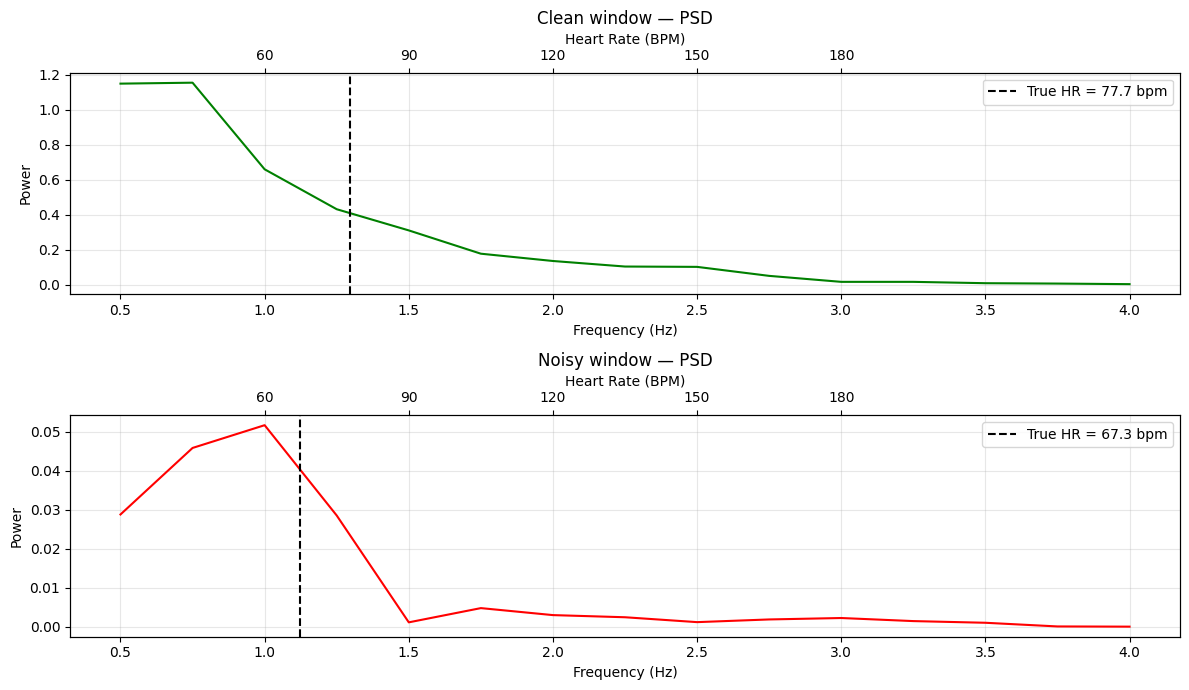

In [10]:
from scipy.signal import welch

fig, axes = plt.subplots(2, 1, figsize=(12, 7))

for ax, idx, color, label in [
    (axes[0], cleanest_idx, 'green', 'Clean'),
    (axes[1], noisiest_idx, 'red',   'Noisy'),
]:
    signal = ppg_clean[idx]
    freqs, psd = welch(signal, fs=25, nperseg=100)

    # Only show 0.5 to 4 Hz (cardiac band)
    mask = (freqs >= 0.5) & (freqs <= 4.0)
    
    ax.plot(freqs[mask], psd[mask], color=color, linewidth=1.5)
    ax.set_ylabel('Power')
    ax.set_xlabel('Frequency (Hz)')
    
    # Add BPM labels on top axis
    ax2 = ax.twiny()
    ax2.set_xlim(ax.get_xlim())
    ax2.set_xticks([1, 1.5, 2, 2.5, 3])
    ax2.set_xticklabels(['60', '90', '120', '150', '180'])
    ax2.set_xlabel('Heart Rate (BPM)')
    
    true_freq = bpm_clean[idx] / 60
    ax.axvline(true_freq, color='black', linestyle='--', linewidth=1.5,
               label=f'True HR = {bpm_clean[idx]:.1f} bpm')
    ax.set_title(f'{label} window — PSD')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

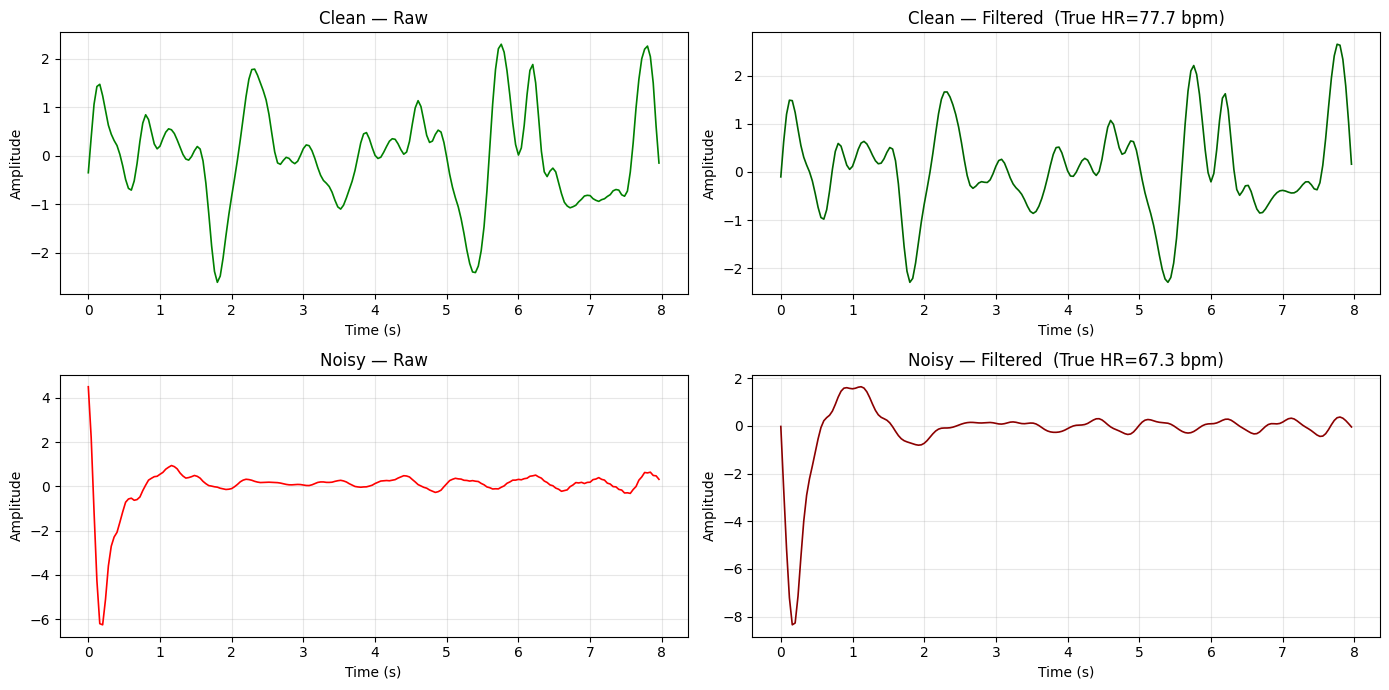

In [11]:
from scipy.signal import butter, sosfiltfilt

def bandpass(signal, low=0.5, high=4.0, fs=25):
    sos = butter(4, [low/(fs/2), high/(fs/2)], btype='band', output='sos')
    return sosfiltfilt(sos, signal)

# Filter both windows
clean_filtered = bandpass(ppg_clean[cleanest_idx])
noisy_filtered = bandpass(ppg_clean[noisiest_idx])

fig, axes = plt.subplots(2, 2, figsize=(14, 7))
time = np.arange(200) / 25.0

# Raw vs filtered waveforms
axes[0,0].plot(time, ppg_clean[cleanest_idx], color='green', linewidth=1.2)
axes[0,0].set_title('Clean — Raw')
axes[0,0].grid(True, alpha=0.3)

axes[0,1].plot(time, clean_filtered, color='darkgreen', linewidth=1.2)
axes[0,1].set_title(f'Clean — Filtered  (True HR={bpm_clean[cleanest_idx]:.1f} bpm)')
axes[0,1].grid(True, alpha=0.3)

axes[1,0].plot(time, ppg_clean[noisiest_idx], color='red', linewidth=1.2)
axes[1,0].set_title('Noisy — Raw')
axes[1,0].grid(True, alpha=0.3)

axes[1,1].plot(time, noisy_filtered, color='darkred', linewidth=1.2)
axes[1,1].set_title(f'Noisy — Filtered  (True HR={bpm_clean[noisiest_idx]:.1f} bpm)')
axes[1,1].grid(True, alpha=0.3)

for ax in axes.flat:
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Amplitude')

plt.tight_layout()
plt.show()

In [ ]:
# Let's build a simple 1D CNN from scratch and understand each part
import torch
import torch.nn as nn

x_example = torch.tensor(ppg_clean[100], dtype=torch.float32)
x_example = x_example.unsqueeze(0).unsqueeze(0)  # → (1, 1, 200)

print("Input shape:", x_example.shape)
print("  batch=1, channels=1, time=200")
print()
print("The network sees 200 numbers and must output 1 number — the HR in bpm")
print(f"For this window the correct answer is: {bpm_clean[100]:.1f} bpm")

Input shape: torch.Size([1, 1, 200])
  batch=1, channels=1, time=200

The network sees 200 numbers and must output 1 number — the HR in bpm
For this window the correct answer is: 68.0 bpm


In [13]:
# Build a simple CNN step by step
# Each Conv1d layer slides a small filter across the 200 time steps
# and learns to detect patterns (like a heartbeat shape)

model = nn.Sequential(
    # Layer 1: detect local patterns (like individual pulse peaks)
    # kernel_size=7 means it looks at 7 samples at a time (0.28 seconds)
    nn.Conv1d(in_channels=1, out_channels=16, kernel_size=7, padding=3),
    nn.ReLU(),
    nn.MaxPool1d(kernel_size=2),   # 200 → 100

    # Layer 2: detect larger patterns (like one full heartbeat cycle)
    nn.Conv1d(in_channels=16, out_channels=32, kernel_size=7, padding=3),
    nn.ReLU(),
    nn.MaxPool1d(kernel_size=2),   # 100 → 50

    # Layer 3: detect even larger patterns (multiple beats = rhythm)
    nn.Conv1d(in_channels=32, out_channels=64, kernel_size=7, padding=3),
    nn.ReLU(),
    nn.AdaptiveAvgPool1d(1),       # 50 → 1 (global average)

    # Flatten and predict HR
    nn.Flatten(),
    nn.Linear(64, 1)               # 64 features → 1 HR value
)

# Pass our example through and watch the shape change
print("Tracing the shape through the network:\n")
x = x_example
print(f"  Input:          {x.shape}")

layers = list(model.children())
for layer in layers:
    x = layer(x)
    print(f"  After {str(layer)[:40]:40s} → {x.shape}")

print(f"\n  Final output: {x.item():.2f} bpm  (untrained, so random)")
print(f"  True answer:  {bpm_clean[100]:.1f} bpm")

Tracing the shape through the network:

  Input:          torch.Size([1, 1, 200])
  After Conv1d(1, 16, kernel_size=(7,), stride=( → torch.Size([1, 16, 200])
  After ReLU()                                   → torch.Size([1, 16, 200])
  After MaxPool1d(kernel_size=2, stride=2, paddi → torch.Size([1, 16, 100])
  After Conv1d(16, 32, kernel_size=(7,), stride= → torch.Size([1, 32, 100])
  After ReLU()                                   → torch.Size([1, 32, 100])
  After MaxPool1d(kernel_size=2, stride=2, paddi → torch.Size([1, 32, 50])
  After Conv1d(32, 64, kernel_size=(7,), stride= → torch.Size([1, 64, 50])
  After ReLU()                                   → torch.Size([1, 64, 50])
  After AdaptiveAvgPool1d(output_size=1)         → torch.Size([1, 64, 1])
  After Flatten(start_dim=1, end_dim=-1)         → torch.Size([1, 64])
  After Linear(in_features=64, out_features=1, b → torch.Size([1, 1])

  Final output: -0.13 bpm  (untrained, so random)
  True answer:  68.0 bpm


In [14]:
# Prepare all subjects' data for training
all_ppg, all_bpm = [], []

for i in range(16):
    ppg_i = mat['data_ppg_wrist'][i, 0]
    bpm_i = mat['data_bpm_values'][i, 0].flatten()
    
    mask = (
        ~np.isnan(ppg_i).any(axis=1) &
        ~np.isinf(ppg_i).any(axis=1) &
        (bpm_i >= 30) & ~np.isnan(bpm_i)
    )
    all_ppg.append(ppg_i[mask])
    all_bpm.append(bpm_i[mask])

# Stack everything
X = np.concatenate(all_ppg, axis=0).astype(np.float32)  # (N, 200)
y = np.concatenate(all_bpm, axis=0).astype(np.float32)  # (N,)

print(f"Total windows : {len(X)}")
print(f"HR range      : {y.min():.1f} – {y.max():.1f} bpm")
print(f"HR mean       : {y.mean():.1f} bpm")

Total windows : 94806
HR range      : 34.3 – 204.8 bpm
HR mean       : 78.1 bpm


In [15]:
# Split by subject — NOT randomly
# Train: subjects 0-12  (13 subjects)
# Test:  subjects 13-15 (3 subjects)

train_ppg, train_bpm = [], []
test_ppg,  test_bpm  = [], []

for i in range(16):
    ppg_i = mat['data_ppg_wrist'][i, 0]
    bpm_i = mat['data_bpm_values'][i, 0].flatten()
    
    mask = (
        ~np.isnan(ppg_i).any(axis=1) &
        ~np.isinf(ppg_i).any(axis=1) &
        (bpm_i >= 30) & ~np.isnan(bpm_i)
    )
    ppg_clean_i = ppg_i[mask].astype(np.float32)
    bpm_clean_i = bpm_i[mask].astype(np.float32)
    
    if i < 13:
        train_ppg.append(ppg_clean_i)
        train_bpm.append(bpm_clean_i)
    else:
        test_ppg.append(ppg_clean_i)
        test_bpm.append(bpm_clean_i)

X_train = np.concatenate(train_ppg)
y_train = np.concatenate(train_bpm)
X_test  = np.concatenate(test_ppg)
y_test  = np.concatenate(test_bpm)

print(f"Train: {len(X_train)} windows from subjects 0–12")
print(f"Test:  {len(X_test)}  windows from subjects 13–15")
print(f"\nTrain HR: {y_train.mean():.1f} bpm mean")
print(f"Test HR:  {y_test.mean():.1f} bpm mean")

Train: 78059 windows from subjects 0–12
Test:  16747  windows from subjects 13–15

Train HR: 75.9 bpm mean
Test HR:  88.4 bpm mean


In [16]:
from torch.utils.data import TensorDataset, DataLoader

# Convert to tensors
# Shape: (N, 1, 200) — add channel dimension
X_train_t = torch.tensor(X_train).unsqueeze(1)
y_train_t = torch.tensor(y_train)
X_test_t  = torch.tensor(X_test).unsqueeze(1)
y_test_t  = torch.tensor(y_test)

# DataLoaders
train_ds     = TensorDataset(X_train_t, y_train_t)
test_ds      = TensorDataset(X_test_t,  y_test_t)
train_loader = DataLoader(train_ds, batch_size=256, shuffle=True)
test_loader  = DataLoader(test_ds,  batch_size=256, shuffle=False)

print(f"Train batches : {len(train_loader)}")
print(f"Test batches  : {len(test_loader)}")

# Setup training
device    = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model     = model.to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.HuberLoss(delta=5.0)

print(f"\nTraining on: {device}")
print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")

Train batches : 305
Test batches  : 66

Training on: cuda
Model parameters: 18,209


In [17]:
# Training loop — 30 epochs
train_losses = []
test_maes    = []

for epoch in range(1, 31):
    # ── Train ──
    model.train()
    epoch_loss = 0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        
        pred = model(X_batch).squeeze()
        loss = criterion(pred, y_batch)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        epoch_loss += loss.item()
    
    # ── Evaluate ──
    model.eval()
    all_preds, all_true = [], []
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            pred = model(X_batch.to(device)).squeeze().cpu()
            all_preds.append(pred.numpy())
            all_true.append(y_batch.numpy())
    
    preds = np.concatenate(all_preds)
    true  = np.concatenate(all_true)
    mae   = np.mean(np.abs(preds - true))
    
    train_losses.append(epoch_loss / len(train_loader))
    test_maes.append(mae)
    
    if epoch % 5 == 0:
        print(f"Epoch {epoch:3d}/30 | loss={train_losses[-1]:.3f} | test MAE={mae:.2f} bpm")

print(f"\nBest MAE: {min(test_maes):.2f} bpm at epoch {test_maes.index(min(test_maes))+1}")

Epoch   5/30 | loss=38.466 | test MAE=12.95 bpm
Epoch  10/30 | loss=36.706 | test MAE=13.03 bpm
Epoch  15/30 | loss=35.428 | test MAE=12.71 bpm
Epoch  20/30 | loss=34.194 | test MAE=11.26 bpm
Epoch  25/30 | loss=33.319 | test MAE=12.38 bpm
Epoch  30/30 | loss=32.906 | test MAE=11.06 bpm

Best MAE: 10.92 bpm at epoch 27


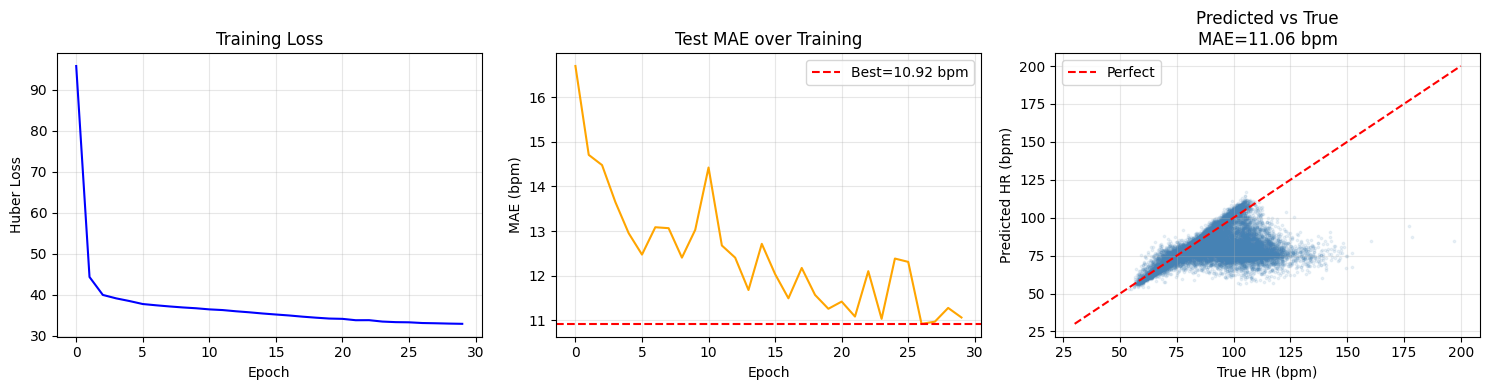

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# ── Plot 1: Training curve ──
axes[0].plot(train_losses, color='blue', linewidth=1.5, label='Train loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Huber Loss')
axes[0].set_title('Training Loss')
axes[0].grid(True, alpha=0.3)

axes[1].plot(test_maes, color='orange', linewidth=1.5)
axes[1].axhline(min(test_maes), color='red', linestyle='--',
                label=f'Best={min(test_maes):.2f} bpm')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MAE (bpm)')
axes[1].set_title('Test MAE over Training')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# ── Plot 2: Predicted vs True scatter ──
axes[2].scatter(true, preds, alpha=0.1, s=3, color='steelblue')
axes[2].plot([30, 200], [30, 200], 'r--', linewidth=1.5, label='Perfect')
axes[2].set_xlabel('True HR (bpm)')
axes[2].set_ylabel('Predicted HR (bpm)')
axes[2].set_title(f'Predicted vs True\nMAE={np.mean(np.abs(preds-true)):.2f} bpm')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [20]:
# Train for 100 more epochs (continuing from epoch 30)
for epoch in range(31, 131):
    # ── Train ──
    model.train()
    epoch_loss = 0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        pred = model(X_batch).squeeze()
        loss = criterion(pred, y_batch)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

    # ── Evaluate ──
    model.eval()
    all_preds, all_true = [], []
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            pred = model(X_batch.to(device)).squeeze().cpu()
            all_preds.append(pred.numpy())
            all_true.append(y_batch.numpy())

    preds = np.concatenate(all_preds)
    true  = np.concatenate(all_true)
    mae   = np.mean(np.abs(preds - true))

    train_losses.append(epoch_loss / len(train_loader))
    test_maes.append(mae)

    if epoch % 10 == 0:
        print(f"Epoch {epoch:3d}/130 | loss={train_losses[-1]:.3f} | test MAE={mae:.2f} bpm")

print(f"\nBest MAE: {min(test_maes):.2f} bpm at epoch {test_maes.index(min(test_maes))+1}")

Epoch  40/130 | loss=32.401 | test MAE=11.71 bpm
Epoch  50/130 | loss=31.967 | test MAE=10.73 bpm
Epoch  60/130 | loss=31.724 | test MAE=10.65 bpm
Epoch  70/130 | loss=31.576 | test MAE=10.27 bpm
Epoch  80/130 | loss=31.431 | test MAE=12.21 bpm
Epoch  90/130 | loss=31.313 | test MAE=10.79 bpm
Epoch 100/130 | loss=31.217 | test MAE=10.21 bpm
Epoch 110/130 | loss=31.118 | test MAE=10.37 bpm
Epoch 120/130 | loss=30.992 | test MAE=10.14 bpm
Epoch 130/130 | loss=30.882 | test MAE=10.16 bpm

Best MAE: 9.95 bpm at epoch 91


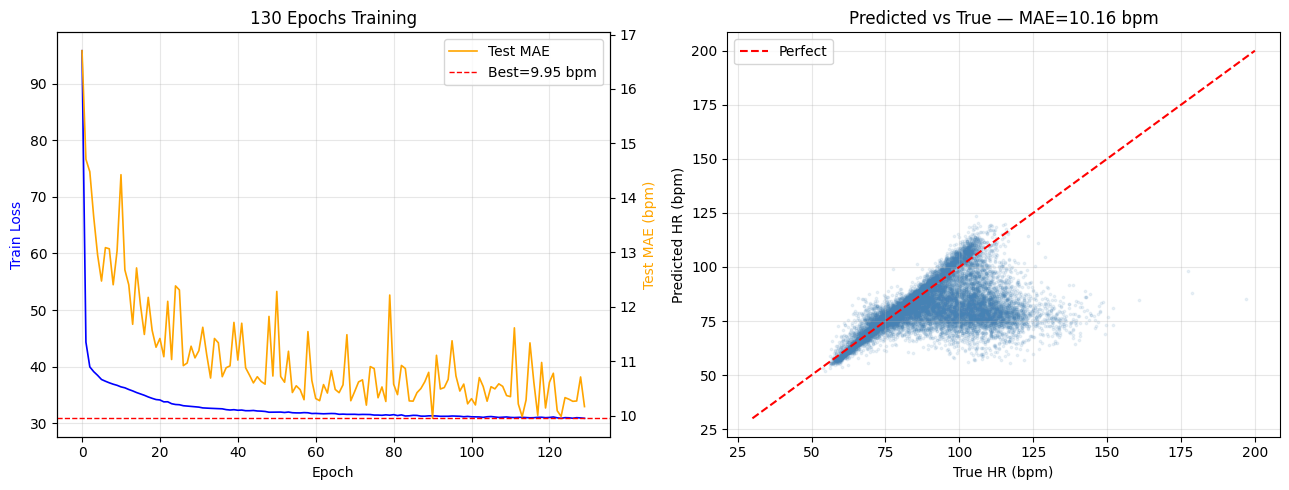

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Full training curve (all 130 epochs)
axes[0].plot(train_losses, color='blue', linewidth=1.2, label='Train loss')
ax_r = axes[0].twinx()
ax_r.plot(test_maes, color='orange', linewidth=1.2, label='Test MAE')
ax_r.axhline(min(test_maes), color='red', linestyle='--', linewidth=1,
             label=f'Best={min(test_maes):.2f} bpm')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Train Loss', color='blue')
ax_r.set_ylabel('Test MAE (bpm)', color='orange')
axes[0].set_title('130 Epochs Training')
ax_r.legend(loc='upper right')
axes[0].grid(True, alpha=0.3)

# Scatter
axes[1].scatter(true, preds, alpha=0.1, s=3, color='steelblue')
axes[1].plot([30, 200], [30, 200], 'r--', linewidth=1.5, label='Perfect')
axes[1].set_xlabel('True HR (bpm)')
axes[1].set_ylabel('Predicted HR (bpm)')
axes[1].set_title(f'Predicted vs True — MAE={np.mean(np.abs(preds-true)):.2f} bpm')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

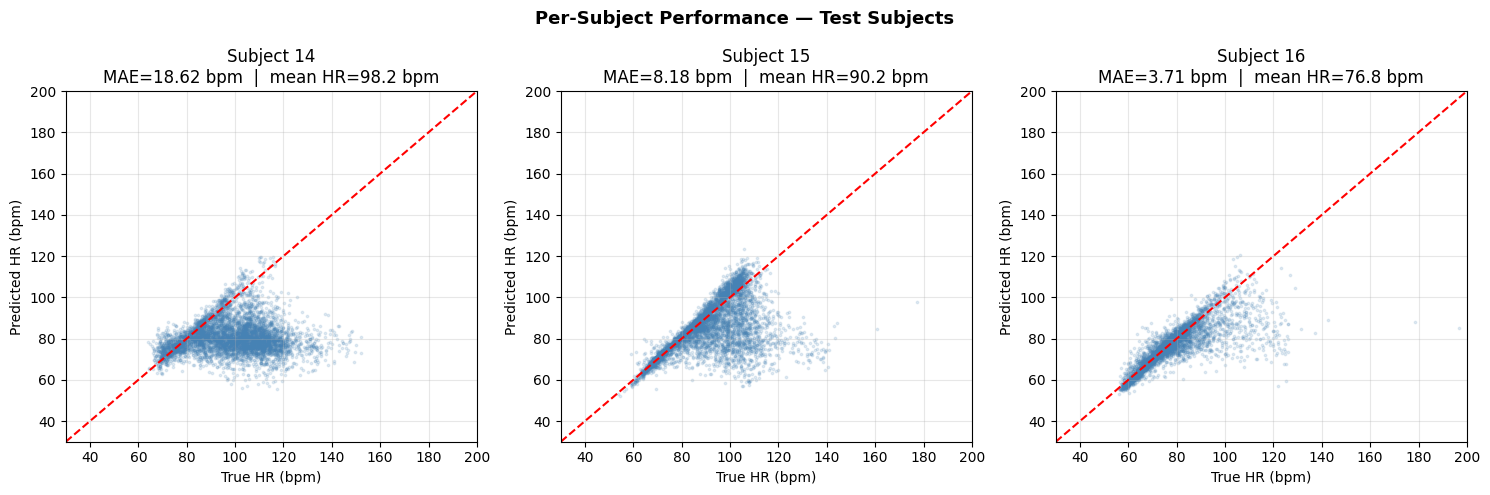

In [22]:
# Evaluate per subject on test subjects (13, 14, 15)
model.eval()

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for plot_idx, subj_idx in enumerate([13, 14, 15]):
    ppg_i = mat['data_ppg_wrist'][subj_idx, 0]
    bpm_i = mat['data_bpm_values'][subj_idx, 0].flatten()
    
    mask = (
        ~np.isnan(ppg_i).any(axis=1) &
        ~np.isinf(ppg_i).any(axis=1) &
        (bpm_i >= 30) & ~np.isnan(bpm_i)
    )
    X_subj = torch.tensor(ppg_i[mask].astype(np.float32)).unsqueeze(1).to(device)
    y_subj = bpm_i[mask]
    
    with torch.no_grad():
        preds_subj = model(X_subj).squeeze().cpu().numpy()
    
    mae  = np.mean(np.abs(preds_subj - y_subj))
    
    axes[plot_idx].scatter(y_subj, preds_subj, alpha=0.15, s=3, color='steelblue')
    axes[plot_idx].plot([30, 200], [30, 200], 'r--', linewidth=1.5)
    axes[plot_idx].set_xlabel('True HR (bpm)')
    axes[plot_idx].set_ylabel('Predicted HR (bpm)')
    axes[plot_idx].set_title(f'Subject {subj_idx+1}\nMAE={mae:.2f} bpm  |  mean HR={y_subj.mean():.1f} bpm')
    axes[plot_idx].grid(True, alpha=0.3)
    axes[plot_idx].set_xlim(30, 200)
    axes[plot_idx].set_ylim(30, 200)

plt.suptitle('Per-Subject Performance — Test Subjects', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()